<a href="https://colab.research.google.com/github/Tejeshwini89/Computer-Vision/blob/main/Contrast%20Enhancement%20(Image)%20%26%20Simple%20Video%20Effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Please upload your image (F1.jpg) and video (12469452_2160_3840_30fps.mp4)


Saving F1.jpg to F1.jpg


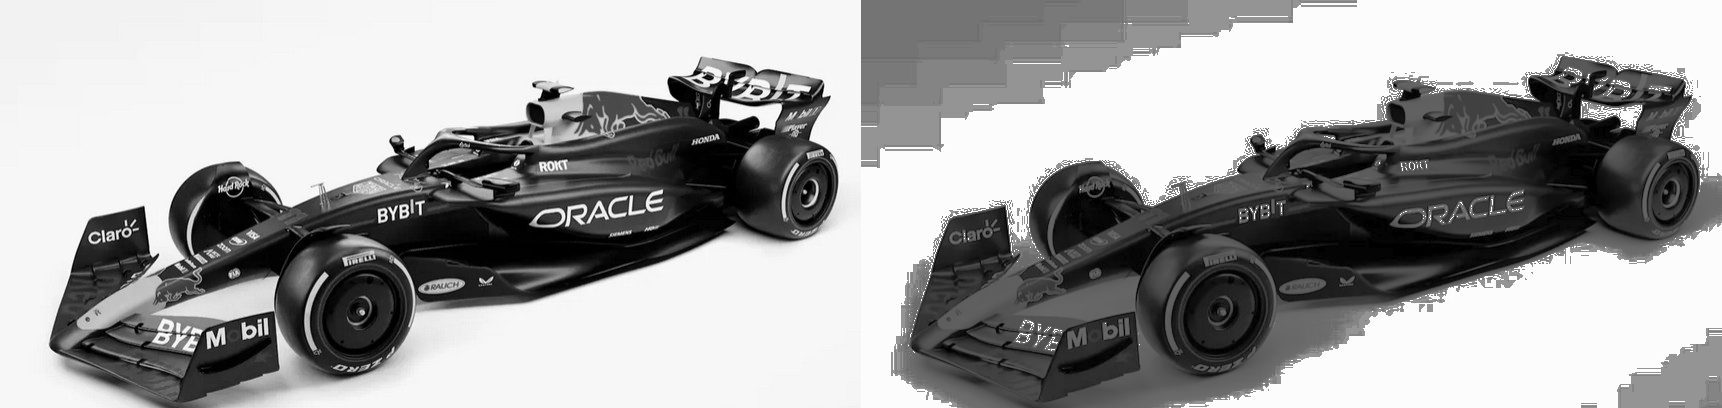

In [ ]:
# ===== Contrast Enhancement (Image) & Simple Video Effects =====

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

# --- Step 1: Upload Files ---
print(" Please upload your image (F1.jpg) and video (12469452_2160_3840_30fps.mp4)")
uploaded = files.upload()

# --- Step 2: Image Contrast Enhancement using Histogram Equalization ---
img = cv2.imread('F1.jpg')

if img is None:
    print("Image not found! Please ensure 'F1.jpg' was uploaded.")
else:
    # Convert to grayscale for equalization
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Histogram Equalization
    equalized = cv2.equalizeHist(gray)

    # Merge grayscale and equalized for comparison
    combined = np.hstack((gray, equalized))
    cv2_imshow(combined)
    cv2.imwrite('/content/contrast_equalized_image.jpg', combined)


In [ ]:
# --- Step 3: Simple Video Effects ---
cap = cv2.VideoCapture('/content/12469452_2160_3840_30fps.mp4')

if not cap.isOpened():
    print("Could not open video. Please ensure it is uploaded correctly.")
else:
    print(" Applying simple video effects (Press ESC to stop)...")
    prev_gray = None

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Video ended.")
            break

        # ----- Effect 1: Color Channel Manipulation -----
        # Swap Red and Blue channels
        color_swap = frame.copy()
        color_swap[:, :, [0, 2]] = color_swap[:, :, [2, 0]]

        # ----- Effect 2: Frame Differencing -----
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if prev_gray is None:
            prev_gray = gray_frame
            continue
        diff = cv2.absdiff(gray_frame, prev_gray)
        prev_gray = gray_frame

        # Convert difference to color for stacking
        diff_color = cv2.cvtColor(diff, cv2.COLOR_GRAY2BGR)

        # Combine original, color-swapped, and frame difference outputs
        combined_frames = np.hstack((frame, color_swap, diff_color))
        cv2_imshow(combined_frames)

        # Stop playback when ESC is pressed
        if cv2.waitKey(1) & 0xFF == 27:
            print(" Stopped by user.")
            break

cap.release()
cv2.destroyAllWindows()